In [1]:
!pip install roboflow ultralytics
!nvidia-smi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 128.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
Tue Jul  7 04:00:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------

In [18]:
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
from collections import Counter
from google.colab import drive
from google.colab import files
from roboflow import Roboflow
from ultralytics import YOLO
import numpy as np
import cv2
import shutil
import random
import sympy
import yaml
import cv2
import os

In [3]:
drive.mount('/content/drive')
drive_dir = "/content/drive/MyDrive/deteccion_componentes_modelo2"
modelo_existente = os.path.exists(f"{drive_dir}/best.pt")
if modelo_existente:
    print("Ya existe un modelo entrenado en Drive.")
else:
    print("No hay modelo guardado todavía.")

Mounted at /content/drive
No hay modelo guardado todavía.


In [4]:
rf = Roboflow(api_key="xEgirQ2EqQJLVtGKjg4y")
project = rf.workspace("valentina-holguin-escudero").project("deteccion_con_pin-vknkg")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to deteccion_con_pin-1 in yolov11:: 100%|██████████| 1985/1985 [00:00<00:00, 8490.68it/s]


In [5]:
for root, dirs, files in os.walk("deteccion_con_pin-1"):
    nivel = root.replace("deteccion_con_pin-1", "").count(os.sep)
    indent = " " * 2 * nivel
    print(f"{indent}{os.path.basename(root)}/")

deteccion_con_pin-1/
  valid/
    images/
    labels/
  train/
    images/
    labels/
  test/
    images/
    labels/


In [6]:
base_dir = "deteccion_con_pin-1"
splits = ["train", "valid", "test"]

output_images = "dataset_completo/images"
output_labels = "dataset_completo/labels"
os.makedirs(output_images, exist_ok=True)
os.makedirs(output_labels, exist_ok=True)

total_img = 0
total_lbl = 0

for split in splits:
    img_dir = os.path.join(base_dir, split, "images")
    lbl_dir = os.path.join(base_dir, split, "labels")

    if not os.path.exists(img_dir):
        print(f"No existe: {img_dir}, se salta.")
        continue

    for filename in os.listdir(img_dir):
        shutil.copy(os.path.join(img_dir, filename), os.path.join(output_images, filename))
        total_img += 1

    if os.path.exists(lbl_dir):
        for filename in os.listdir(lbl_dir):
            shutil.copy(os.path.join(lbl_dir, filename), os.path.join(output_labels, filename))
            total_lbl += 1

print(f"Total imágenes: {total_img}, total labels: {total_lbl}")
print("Todo unificado en dataset_completo/")

Total imágenes: 990, total labels: 990
Todo unificado en dataset_completo/


In [7]:
with open("deteccion_con_pin-1/data.yaml", "r") as f:
    data_yaml = yaml.safe_load(f)

original_names = data_yaml["names"]
print("Clases originales:", original_names)

Clases originales: ['capacitor-horizontal', 'capacitor-vertical', 'diode-horizontal', 'diode-vertical', 'pinned', 'resistor-horizontal', 'resistor-vertical']


In [8]:
def contar_labels_por_clase(labels_dir, original_names):
    contador = Counter()
    total_archivos = 0
    total_lineas = 0

    for root, _, files in os.walk(labels_dir):
        for f in files:
            if f.endswith(".txt"):
                total_archivos += 1
                path = os.path.join(root, f)
                with open(path, "r") as file:
                    for line in file:
                        line = line.strip()
                        if not line:
                            continue
                        class_id = int(line.split()[0])
                        contador[class_id] += 1
                        total_lineas += 1

    print(f"  Archivos .txt: {total_archivos} | Anotaciones: {total_lineas}")
    for idx, nombre in enumerate(original_names):
        print(f"    {idx} ({nombre}): {contador.get(idx, 0)} labels")
    return contador

base_dir = "deteccion_con_pin-1"

for split in ["train", "valid", "test"]:
    labels_path = os.path.join(base_dir, split, "labels")
    if os.path.exists(labels_path):
        print(f"\n--- {split} ---")
        contar_labels_por_clase(labels_path, original_names)
    else:
        print(f"\n--- {split} --- (no existe la carpeta {labels_path})")


--- train ---
  Archivos .txt: 790 | Anotaciones: 8050
    0 (capacitor-horizontal): 318 labels
    1 (capacitor-vertical): 175 labels
    2 (diode-horizontal): 334 labels
    3 (diode-vertical): 278 labels
    4 (pinned): 5023 labels
    5 (resistor-horizontal): 994 labels
    6 (resistor-vertical): 928 labels

--- valid ---
  Archivos .txt: 126 | Anotaciones: 1176
    0 (capacitor-horizontal): 39 labels
    1 (capacitor-vertical): 27 labels
    2 (diode-horizontal): 56 labels
    3 (diode-vertical): 39 labels
    4 (pinned): 746 labels
    5 (resistor-horizontal): 152 labels
    6 (resistor-vertical): 117 labels

--- test ---
  Archivos .txt: 74 | Anotaciones: 697
    0 (capacitor-horizontal): 29 labels
    1 (capacitor-vertical): 14 labels
    2 (diode-horizontal): 29 labels
    3 (diode-vertical): 26 labels
    4 (pinned): 458 labels
    5 (resistor-horizontal): 69 labels
    6 (resistor-vertical): 72 labels


In [9]:
rename_map = {
    "capacitor-horizontal": "capacitor",
    "capacitor-vertical": "capacitor",
    "diode-horizontal": "led",
    "diode-vertical": "led",
    "resistor-horizontal": "resistencia",
    "resistor-vertical": "resistencia",
    "pinned": "pin"
}

new_names = ["capacitor", "led", "resistencia", "pin"]
new_index = {name: i for i, name in enumerate(new_names)}

old_to_new = {}
for old_idx, old_name in enumerate(original_names):
    if old_name in rename_map:
        old_to_new[old_idx] = new_index[rename_map[old_name]]
    else:
        old_to_new[old_idx] = None

print("Mapeo índice original -> índice nuevo:", old_to_new)

Mapeo índice original -> índice nuevo: {0: 0, 1: 0, 2: 1, 3: 1, 4: 3, 5: 2, 6: 2}


In [10]:
filtered_dir = "dataset_filtrado"
os.makedirs(f"{filtered_dir}/images", exist_ok=True)
os.makedirs(f"{filtered_dir}/labels", exist_ok=True)

src_images = "dataset_completo/images"
src_labels = "dataset_completo/labels"

contador_imgs = 0
for label_file in os.listdir(src_labels):
    path_label = os.path.join(src_labels, label_file)

    with open(path_label, "r") as f:
        lines = f.readlines()

    nuevas_lineas = []
    for line in lines:
        partes = line.strip().split()
        if not partes:
            continue
        old_cls = int(partes[0])
        new_cls = old_to_new.get(old_cls)
        if new_cls is not None:
            partes[0] = str(new_cls)
            nuevas_lineas.append(" ".join(partes))

    if nuevas_lineas:
        with open(os.path.join(filtered_dir, "labels", label_file), "w") as f:
            f.write("\n".join(nuevas_lineas))

        base_name = os.path.splitext(label_file)[0]
        for ext in [".jpg", ".jpeg", ".png"]:
            img_path = os.path.join(src_images, base_name + ext)
            if os.path.exists(img_path):
                shutil.copy(img_path, os.path.join(filtered_dir, "images", base_name + ext))
                contador_imgs += 1
                break

print(f"Total imágenes con clases relevantes: {contador_imgs}")

Total imágenes con clases relevantes: 989


In [11]:
random.seed(42)

all_images = os.listdir(f"{filtered_dir}/images")
random.shuffle(all_images)

n = len(all_images)
n_train = int(n * 0.70)
n_test = int(n * 0.20)

train_files = all_images[:n_train]
test_files = all_images[n_train:n_train + n_test]
val_files = all_images[n_train + n_test:]

print(f"Train: {len(train_files)} | Test: {len(test_files)} | Val: {len(val_files)}")

final_dir = "dataset_final"

def copiar_split(files, split_name):
    os.makedirs(f"{final_dir}/{split_name}/images", exist_ok=True)
    os.makedirs(f"{final_dir}/{split_name}/labels", exist_ok=True)
    for img_file in files:
        base_name = os.path.splitext(img_file)[0]
        shutil.copy(f"{filtered_dir}/images/{img_file}", f"{final_dir}/{split_name}/images/{img_file}")
        label_path = f"{filtered_dir}/labels/{base_name}.txt"
        if os.path.exists(label_path):
            shutil.copy(label_path, f"{final_dir}/{split_name}/labels/{base_name}.txt")

copiar_split(train_files, "train")
copiar_split(test_files, "test")
copiar_split(val_files, "val")

Train: 692 | Test: 197 | Val: 100


In [12]:
data_yaml_final = {
    "train": os.path.abspath(f"{final_dir}/train/images"),
    "val": os.path.abspath(f"{final_dir}/val/images"),
    "test": os.path.abspath(f"{final_dir}/test/images"),
    "nc": len(new_names),
    "names": new_names
}

with open(f"{final_dir}/data.yaml", "w") as f:
    yaml.dump(data_yaml_final, f)

print(data_yaml_final)

{'train': '/content/dataset_final/train/images', 'val': '/content/dataset_final/val/images', 'test': '/content/dataset_final/test/images', 'nc': 4, 'names': ['capacitor', 'led', 'resistencia', 'pin']}


In [13]:
model = YOLO("yolo11n.pt")
results = model.train(
    data=f"{final_dir}/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    name="deteccion_con_pin",
    cache= False,
    workers=2,
)

os.makedirs(drive_dir, exist_ok=True)

shutil.copy("runs/detect/deteccion_con_pin/weights/best.pt", f"{drive_dir}/best.pt")
shutil.copy("runs/detect/deteccion_con_pin/weights/last.pt", f"{drive_dir}/last.pt")
shutil.copy(f"{final_dir}/data.yaml", f"{drive_dir}/data.yaml")
shutil.copytree(final_dir, f"{drive_dir}/dataset_final", dirs_exist_ok=True)

print("Modelo y dataset guardados en Drive:", drive_dir)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset_final/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=deteccion_con_pin, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

In [14]:
best_model = YOLO(f"{drive_dir}/best.pt")

with open(f"{drive_dir}/data.yaml", "r") as f:
    data_yaml_final = yaml.safe_load(f)

new_names = data_yaml_final["names"]
final_dir = f"{drive_dir}/dataset_final"

print("Modelo cargado. Clases:", new_names)

Modelo cargado. Clases: ['capacitor', 'led', 'resistencia', 'pin']


In [15]:
metrics = best_model.val(data=f"{drive_dir}/data.yaml", split="test")
print("mAP50-95:", metrics.box.map)
print("mAP50:", metrics.box.map50)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1228.9±183.8 MB/s, size: 56.6 KB)
val: Scanning /content/dataset_final/test/labels... 197 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 197/197 2.1Kit/s 0.1s
val: New cache created: /content/dataset_final/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.7it/s 4.8s
                   all        197       1826      0.909      0.886      0.902      0.594
             capacitor         92        105      0.955          1      0.995      0.811
                   led         65        121      0.931      0.967      0.973      0.667
           resistencia         69        446      0.953      0.996      0.981      0.631
                   pin        197       1154      0.798       0.58      

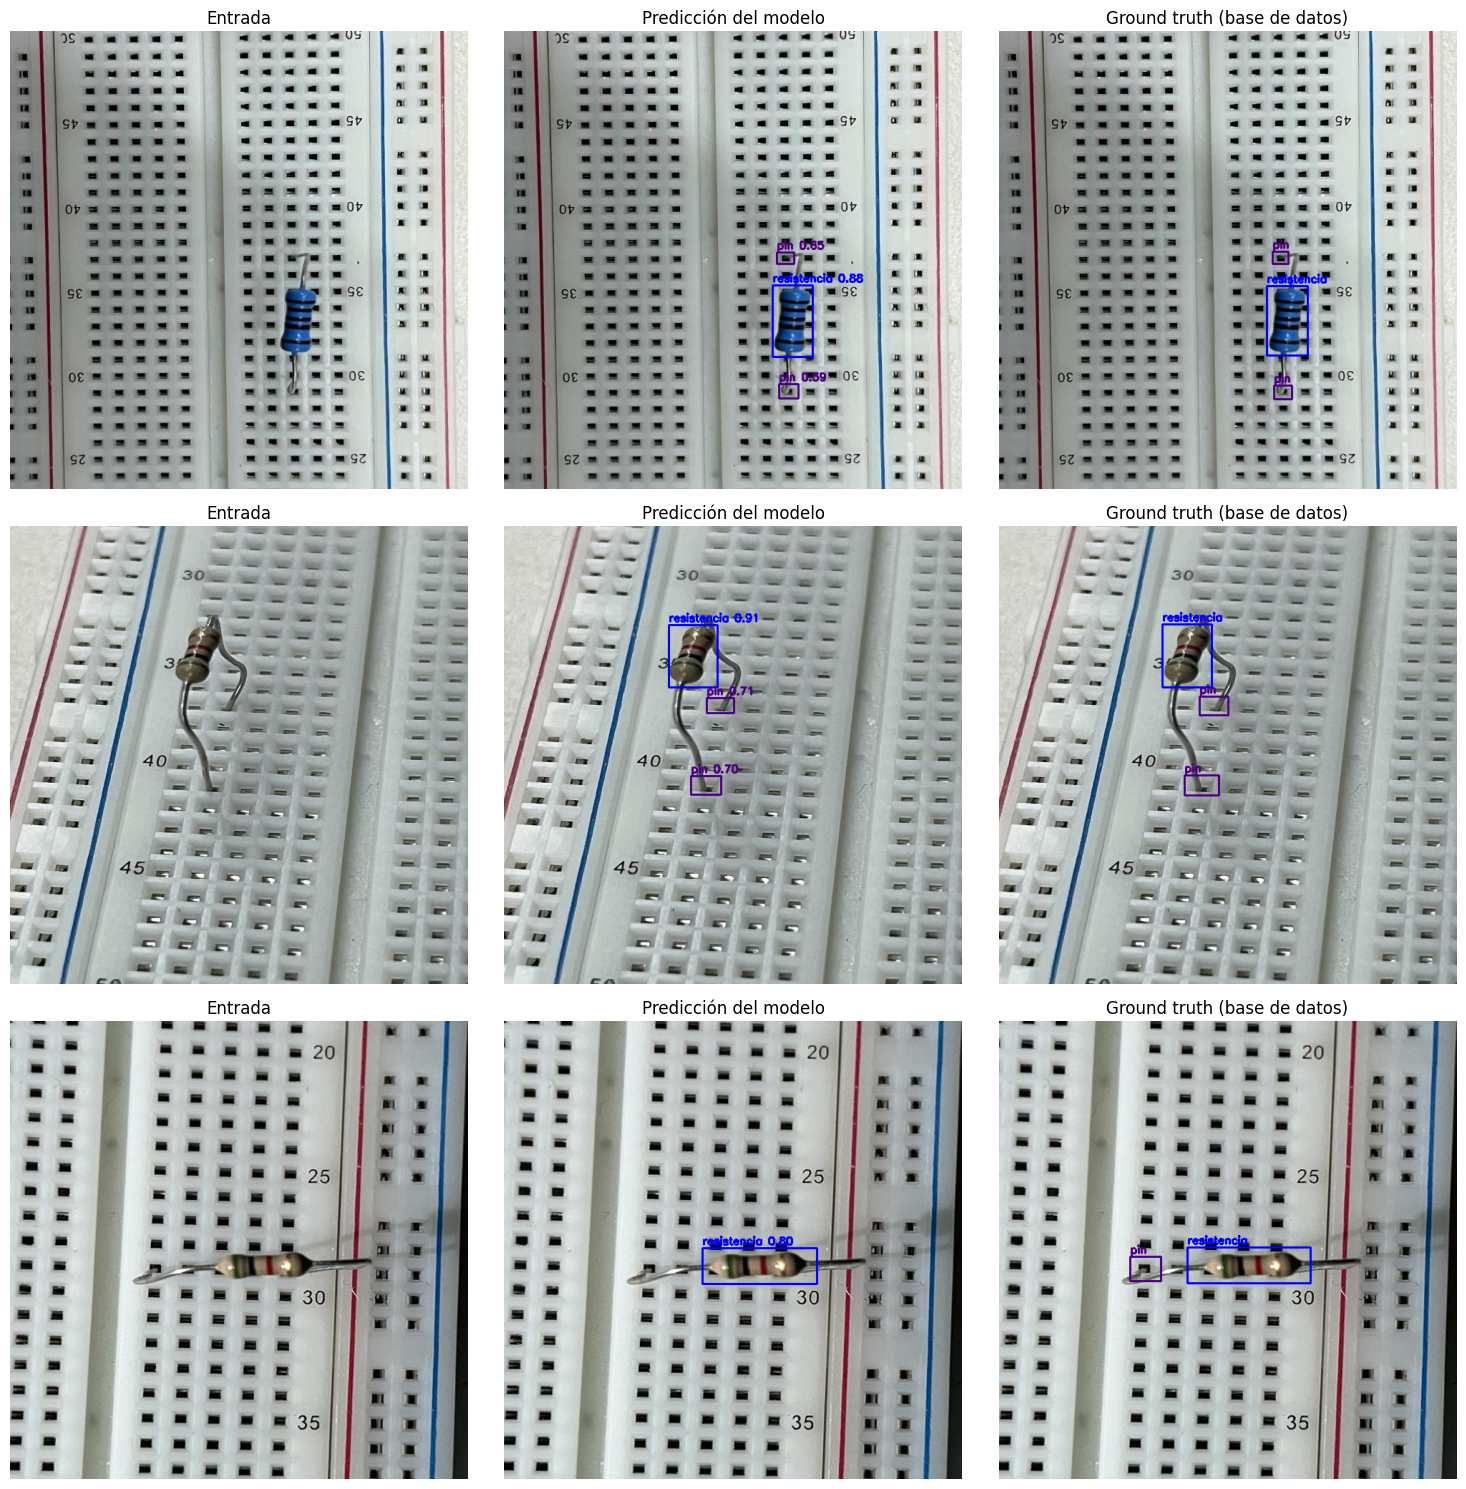

In [16]:
random.seed(8)
muestras = random.sample(val_files, 3)

colores = {0: (0, 255, 0), 1: (255, 0, 0), 2: (0, 0, 255), 3: (75, 0, 130)}

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for i, img_file in enumerate(muestras):
    base_name = os.path.splitext(img_file)[0]
    img_path = f"{final_dir}/val/images/{img_file}"
    label_path = f"{final_dir}/val/labels/{base_name}.txt"

    img_original = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h, w = img_original.shape[:2]

    axes[i, 0].imshow(img_original)
    axes[i, 0].set_title("Entrada")
    axes[i, 0].axis("off")

    pred = best_model.predict(img_path, verbose=False)[0]
    img_pred = img_original.copy()
    for box in pred.boxes:
        cls = int(box.cls[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])
        cv2.rectangle(img_pred, (x1, y1), (x2, y2), colores.get(cls, (255,255,0)), 2)
        cv2.putText(img_pred, f"{new_names[cls]} {conf:.2f}", (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, colores.get(cls, (255,255,0)), 2)
    axes[i, 1].imshow(img_pred)
    axes[i, 1].set_title("Predicción del modelo")
    axes[i, 1].axis("off")

    img_gt = img_original.copy()
    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f.readlines():
                cls, xc, yc, bw, bh = map(float, line.strip().split())
                cls = int(cls)
                x1 = int((xc - bw/2) * w)
                y1 = int((yc - bh/2) * h)
                x2 = int((xc + bw/2) * w)
                y2 = int((yc + bh/2) * h)
                cv2.rectangle(img_gt, (x1, y1), (x2, y2), colores.get(cls, (255,255,0)), 2)
                cv2.putText(img_gt, new_names[cls], (x1, y1-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, colores.get(cls, (255,255,0)), 2)
    axes[i, 2].imshow(img_gt)
    axes[i, 2].set_title("Ground truth (base de datos)")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()
img_nueva_path = list(uploaded.keys())[0]

best_model = YOLO(f"{drive_dir}/best.pt")
new_names = ["capacitor", "led", "resistencia", "pin"]
img_pil = Image.open(img_nueva_path)
img_pil = ImageOps.exif_transpose(img_pil)
img_pil = img_pil.convert("RGB")
img_resized = img_pil.resize((640, 640), Image.BILINEAR)
img_array = np.array(img_resized)
resultado = best_model.predict(img_array, conf=0.25, verbose=False)[0]
img = img_array.copy()
colores = {0: (0, 255, 0), 1: (255, 0, 0), 2: (0, 0, 255), 3: (128, 0, 128)}

for box in resultado.boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    color = colores.get(cls, (255, 255, 0))
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
    cv2.putText(img, f"{new_names[cls]} {conf:.2f}", (x1, y1 - 8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Detección en imagen nueva")
plt.show()

for box in resultado.boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    print(f"{new_names[cls]} - confianza: {conf:.2f}")